In [1]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
import itertools
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'is_gesture'

WINDOW_SIZE_SAMPLES = 100
WINDOW_STRIDE_SAMPLES = 25
SAMPLING_RATE_HZ = 70  # in Hz
TOUCH_MOVE_THRESHOLD = 0.01  # Radians
WINDOW_GESTURE_MAJORITY_THRESHOLD = 0.4  # 40%

In [3]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        rtParent.title AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title = 'No Gesture' THEN 'no' ELSE 'yes' END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title != 'Szenarien'
),

no_gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        'No Gesture' AS gesture,
        'No Gesture' AS parent_gesture,
        s.participant_id,
        'semi' AS is_gesture,
        NULL  AS group_id -- TODO : Assign group_id
    FROM sensorData sd
    LEFT JOIN gesture_samples gs 
      ON gs.id = sd.id -- Check if this row was already labeled as a gesture
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    
    -- Exclude rows that were found in gesture_samples (gs.id IS NULL)
    -- Also keep your original session_task_id and 'Szenarien' filters
    WHERE gs.id IS NULL
      AND sd.session_task_id IN (
          SELECT DISTINCT session_task_id FROM preciseMarker
      )
      AND rtParent.title != 'Szenarien'
)

-- Final combined dataset
SELECT * FROM gesture_samples
UNION ALL
SELECT * FROM no_gesture_samples
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [4]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [5]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")

In [6]:
# Augment the data in a way, that you copy all rows with their columns, only change the order of the touch_X_* columns randomly, also append a unique suffix to the id fields, group_id, session_task_id, participant_id, so that they are unique in the new dataset
def augment_data(df, n_augmentations=1):
    augmented_dfs = []
    
    for i in range(n_augmentations):
        df_aug = df.copy()
        
        # Shuffle touch columns
        shuffled_indices = np.random.permutation(5) + 1  # Touch indices from 1 to 5
        for j, new_idx in enumerate(shuffled_indices, start=1):
            for suffix in ['position', 'pressure', 'channel']:
                df_aug[f'touch_{j}_{suffix}'] = df[f'touch_{new_idx}_{suffix}']
        
        # Append unique suffix to id fields
        df_aug['id'] = df_aug['id'].astype(str) + f'_aug{i}'
        df_aug['group_id'] = df_aug['group_id'].astype(str) + f'_aug{i}'
        df_aug['session_task_id'] = df_aug['session_task_id'].astype(str) + f'_aug{i}'
        df_aug['participant_id'] = df_aug['participant_id'].astype(str) + f'_aug{i}'
        
        augmented_dfs.append(df_aug)
    
    return pd.concat([df] + augmented_dfs, ignore_index=True)

def augment_data_all_permutations(df, limit=None):
    augmented_dfs = []

    # All 5! = 120 permutations of touch indices 1..5
    permutations = list(itertools.permutations(range(1, 6)))

    for i, perm in enumerate(permutations):
        if limit is not None and i >= limit:
            break

        df_aug = df.copy()

        # Reorder touch columns according to permutation
        for j, new_idx in enumerate(perm, start=1):
            for suffix in ['position', 'pressure', 'channel']:
                df_aug[f'touch_{j}_{suffix}'] = df[f'touch_{new_idx}_{suffix}']

        # Append unique suffix to id fields
        suffix = f'_perm{i}'
        df_aug['id'] = df_aug['id'].astype(str) + suffix
        df_aug['group_id'] = df_aug['group_id'].astype(str) + suffix
        df_aug['session_task_id'] = df_aug['session_task_id'].astype(str) + suffix
        df_aug['participant_id'] = df_aug['participant_id'].astype(str) + suffix

        augmented_dfs.append(df_aug)

    # Original + all permutations
    return pd.concat([df] + augmented_dfs, ignore_index=True)

In [7]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        df_raw[col] = df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
df_raw['motor_angle'] = df_raw.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [8]:
df_raw[LABEL_COLUMN].value_counts()

is_gesture
semi    317926
yes      52710
no       25966
Name: count, dtype: int64

In [9]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [10]:
df_raw.groupby(["participant_id"]).size()

participant_id
5d52daf3-c962-4db6-a8f8-298a0bb01733    49949
6331fbd1-76bb-48d6-92a2-80a55a70d134    37711
696b4743-9d39-4fb1-8271-90e7d48652af    26221
6a1b56e6-47ce-43cb-96cb-713d055d8f6d    67623
707c3867-fe15-4b05-bf7b-fc5f3b501fb1    49778
754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    48069
d3b39f0f-b799-4d69-b7a3-a663e5c7438f    55706
fdd02af8-c764-43ba-8247-c612f85568b4    61545
dtype: int64

In [11]:
# Check all columns with nan values
nan_columns = df_raw.columns[df_raw.isna().any()].tolist()
nan_columns

['touch_1_position',
 'touch_1_pressure',
 'touch_1_channel',
 'touch_2_position',
 'touch_2_pressure',
 'touch_2_channel',
 'touch_3_position',
 'touch_3_pressure',
 'touch_3_channel',
 'touch_4_position',
 'touch_4_pressure',
 'touch_4_channel',
 'touch_5_position',
 'touch_5_pressure',
 'touch_5_channel',
 'group_id']

In [12]:
import pandas as pd
import numpy as np

TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

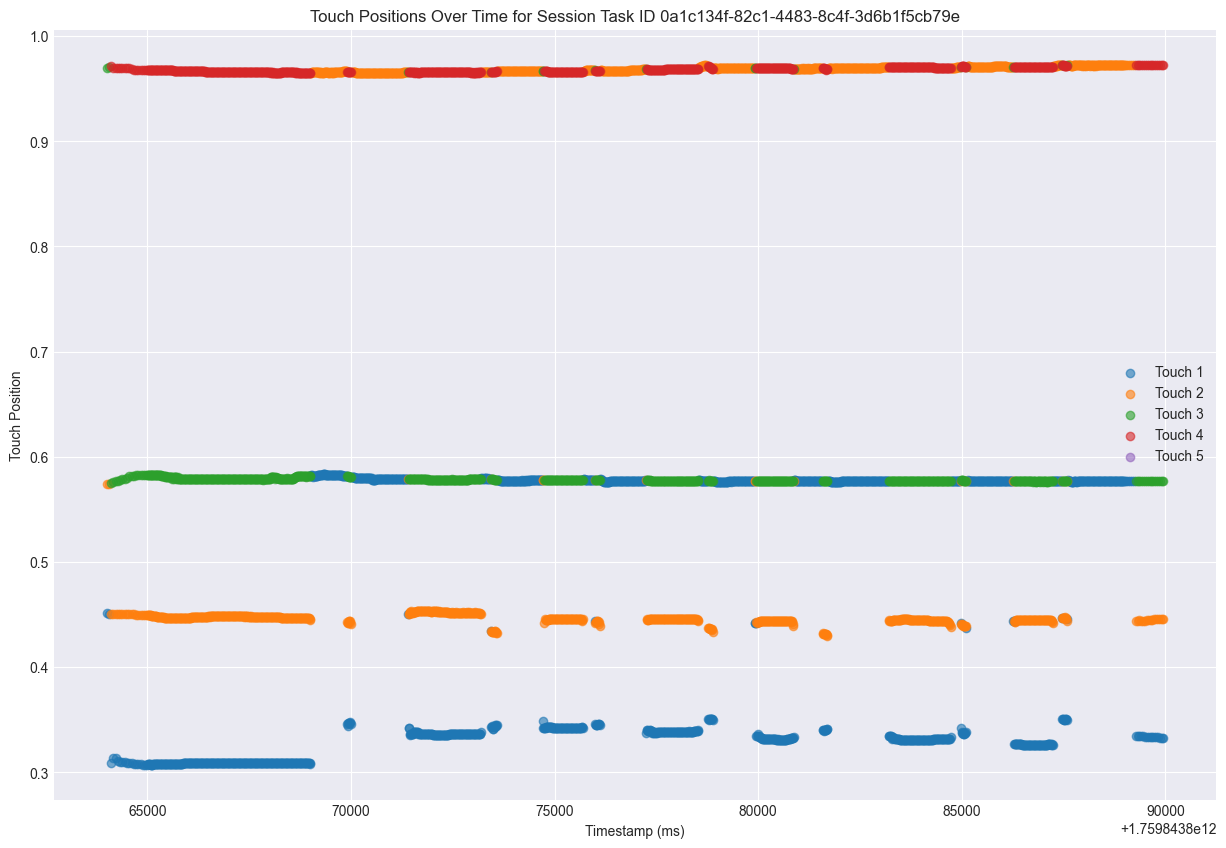

In [13]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_raw["session_task_id"].unique()[0]
session_df = df_raw[df_raw["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [14]:
# Stabilize dataframe, but only the first session_task_id for testing
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

df_clean = final_df.join(stabilized_touch_data)

print("Stabilization Complete.")

Stabilization Complete.


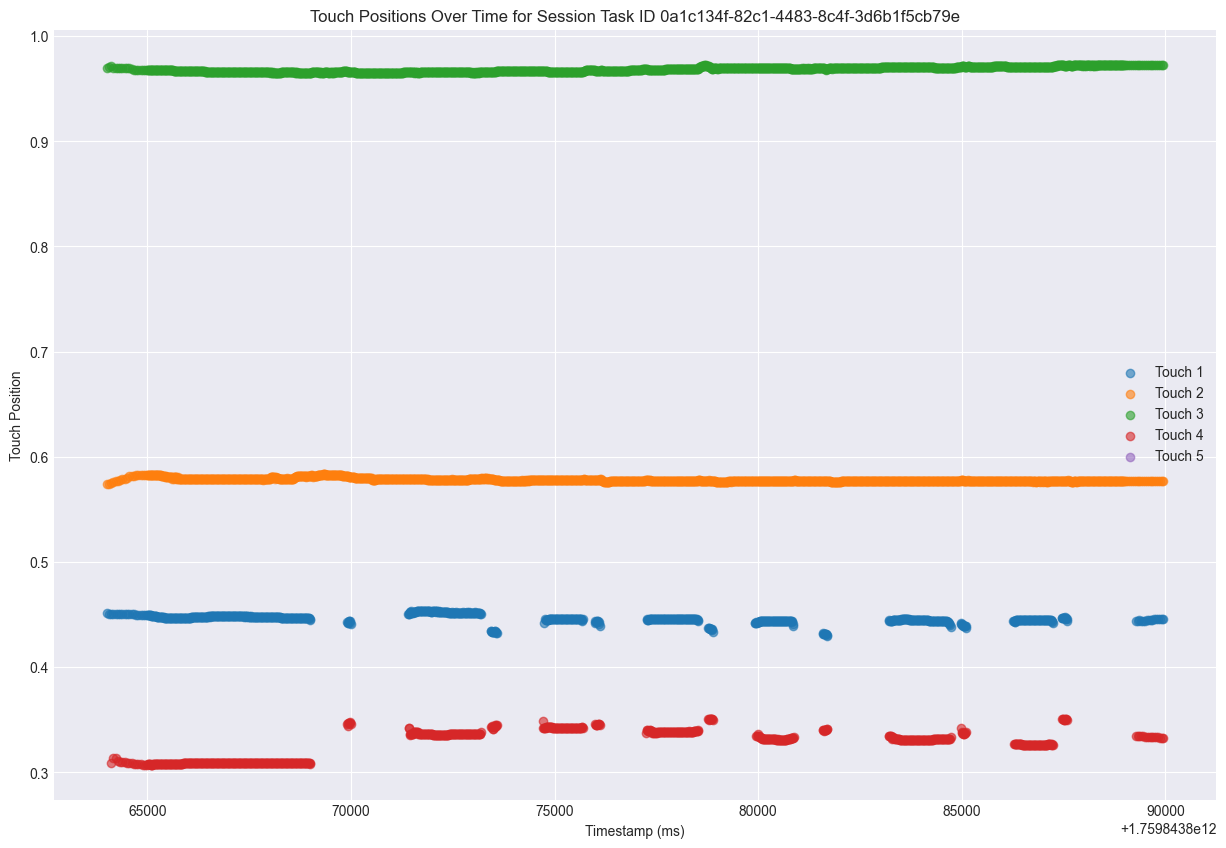

In [15]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_clean["session_task_id"].unique()[0]
session_df = df_clean[df_clean["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [16]:
# Set 0 for null values in position, pressure, channel columns for touches 2 to 5
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    df_clean[position_col] = df_clean[position_col].fillna(0)
    df_clean[pressure_col] = df_clean[pressure_col].fillna(0)
    df_clean[channel_col] = df_clean[channel_col].fillna(0)
df_clean[nan_columns].isna().sum()

touch_1_position         0
touch_1_pressure         0
touch_1_channel          0
touch_2_position         0
touch_2_pressure         0
touch_2_channel          0
touch_3_position         0
touch_3_pressure         0
touch_3_channel          0
touch_4_position         0
touch_4_pressure         0
touch_4_channel          0
touch_5_position         0
touch_5_pressure         0
touch_5_channel          0
group_id            317926
dtype: int64

In [17]:
# Print the min, max and mean count of samples per group_id
grouped = df_clean.groupby('group_id').size()
print(f"Min samples per group_id: {grouped.min()}")
print(f"Max samples per group_id: {grouped.max()}")
print(f"Mean samples per group_id: {grouped.mean():.2f}")

# Print the parent_gesture for the group_id with the maximum samples
max_group_id = grouped.idxmax()
max_parent_gesture = df_clean[df_clean['group_id'] == max_group_id]['parent_gesture'].iloc[0]
print(f"Parent gesture for group_id with max samples ({max_group_id}): {max_parent_gesture}")

# Print the parent_gesture for the group_id with the minimum samples
min_group_id = grouped.idxmin()
min_parent_gesture = df_clean[df_clean['group_id'] == min_group_id]['parent_gesture'].iloc[0]
print(f"Parent gesture for group_id with min samples ({min_group_id}): {min_parent_gesture}")

# Print the count of samples for the No Gesture parent_gesture that has the max samples
no_gesture_grouped = df_clean[df_clean['parent_gesture'] == 'No Gesture'].groupby('group_id').size()
print(f"Max samples for 'No Gesture' group_id: {no_gesture_grouped.max()}")
gesture_grouped = df_clean[df_clean['parent_gesture'] != 'No Gesture'].groupby('group_id').size()
print(f"Max samples for Gestures group_id: {gesture_grouped.max()}")


Min samples per group_id: 8
Max samples per group_id: 862
Mean samples per group_id: 61.04
Parent gesture for group_id with max samples (2025-10-07 13:53:22): No Gesture
Parent gesture for group_id with min samples (2025-12-29 10:09:06): Two-Finger Tap
Max samples for 'No Gesture' group_id: 862
Max samples for Gestures group_id: 406


In [18]:
# The window size for windows that contain a full gesture
FULL_GESTURE_WINDOW_SIZE = gesture_grouped.max() + 10  # add some buffer
print(f"Full gesture window size: {FULL_GESTURE_WINDOW_SIZE}")

def pad_pre(sequence_2d, target_len):
    T, F = sequence_2d.shape
    if T == target_len:
        return sequence_2d

    if T > target_len:
        # truncate: keep last target_len steps (end of gesture)
        return sequence_2d[-target_len:, :]

    # T < target_len: pre-pad with zeros at the start
    pad_len = target_len - T
    pad_block = np.zeros((pad_len, F), dtype=sequence_2d.dtype)
    return np.vstack([pad_block, sequence_2d])


Full gesture window size: 416


In [19]:
# Print unique values of label column
print("Unique values in label column:", df_clean[LABEL_COLUMN].unique())

Unique values in label column: ['semi' 'yes' 'no']


In [ ]:
df_clean = augment_data_all_permutations(df_clean, limit=10)

In [20]:
X_windows = []
y_windows = []
meta_windows = []

for (sid, pid), g in df_clean.groupby(["session_task_id", "participant_id"]):
    sensor_data = g[SENSOR_COLUMNS].to_numpy()
    labels = g[LABEL_COLUMN].to_numpy()
    
    n_samples = sensor_data.shape[0]
    start_idx = 0
    
    while start_idx + FULL_GESTURE_WINDOW_SIZE <= n_samples:
        end_idx = start_idx + FULL_GESTURE_WINDOW_SIZE
        window_data = sensor_data[start_idx:end_idx, :]
        window_labels = labels[start_idx:end_idx]
        
        # Determine the label for the window based on if a full gesture is included in the window, partial gestures do not count
        # We do that by checking if yes is included in the window and no is at the start and end of the window
        gesture_count = np.sum(window_labels == 'yes')
        no_gesture_at_edges = (window_labels[0] != 'yes') and (window_labels[-1] != 'yes')
        if gesture_count / FULL_GESTURE_WINDOW_SIZE >= WINDOW_GESTURE_MAJORITY_THRESHOLD and no_gesture_at_edges:
            window_label = 1
        else:
            window_label = 0
        
        X_windows.append(window_data)
        y_windows.append(window_label)
        meta_windows.append({
            'session_task_id': sid,
            'participant_id': pid,
            'start_index': start_idx,
            'end_index': end_idx
        })
        
        start_idx += WINDOW_STRIDE_SAMPLES
X_windows = np.array(X_windows)
y_windows = np.array(y_windows)
meta_windows = pd.DataFrame(meta_windows)

In [21]:
# Print the number of windows created plus the amount of labels
print(f"Total windows created: {X_windows.shape[0]}")
# For each label, print the count
unique, counts = np.unique(y_windows, return_counts=True)
label_counts = dict(zip(unique, counts))
for label, count in label_counts.items():
    print(f"Label {label}: {count} windows")

Total windows created: 12516
Label 0: 12083 windows
Label 1: 433 windows


In [22]:
def extract_features(window, is_padded_window):
    features = []
    feature_names = [] # for debug purposes we store the names of each feature at the same index
    
    # Assume sensor column order from SENSOR_COLUMNS
    # Indices: button=0, motor=1, touch_pos=[2,5,8,11,14], touch_press=[3,6,9,12,15]
    button_col = 0
    motor_col = 1
    touch_channel_cols = [4, 7, 10, 13, 16]  # touch_X_channel indices
    touch_pressure_cols = [3, 6, 9, 12, 15]  # touch_X_pressure indices
    touch_position_cols = [2, 5, 8, 11, 14]  # touch_X_position indices
    original_length_col = len(SENSOR_COLUMNS)  # last column is original length

    button_press_data = window[:, button_col]
    motor_data = window[:, motor_col]
    touch_pressures = window[:, touch_pressure_cols]
    touch_positions = window[:, touch_position_cols]
    # Only consider touch positions where the pressure > 0
    valid_mask = touch_pressures > 0
    touch_positions = touch_positions[valid_mask]
    original_length = int(window[0, original_length_col]) if is_padded_window else window.shape[0]

    # A 1 signalizes the button was pressed, this can happen multiple times in a window, so we first have to extract each consecutive time a button was pressed, plus the amount of samples for each time
    binary_button_press = (button_press_data > 0).astype(int)
    padded_button_press = np.concatenate(([0], binary_button_press, [0]))
    button_press_diff = np.diff(padded_button_press)
    button_press_starts = np.where(button_press_diff == 1)[0]
    button_press_ends = np.where(button_press_diff == -1)[0]
    button_press_durations = button_press_ends - button_press_starts

    def circular_range(angles):
        # 1. Sort the angles
        sorted_angles = np.sort(angles)
        # 2. Calculate gaps between neighbors
        gaps = np.diff(sorted_angles)
        # 3. Calculate the wrap-around gap (last to first)
        wrap_gap = (2 * np.pi - sorted_angles[-1]) + sorted_angles[0]
        # 4. Combine all gaps
        all_gaps = np.append(gaps, wrap_gap)
        # 5. Range is the full circle minus the biggest empty space
        return 2 * np.pi - np.max(all_gaps)
    
    def add_feature(name, value):
        features.append(value)
        feature_names.append(name)

    # Button Features
    # 1. Button pressed at all?
    add_feature("button_pressed_any", np.any(binary_button_press))
    # # 2. How often was the button pressed (changed from 0 to 1 and vice versa) and how often was it let go
    add_feature("button_press_count", len(button_press_starts))
    # # 3. Mean (raw + durations)
    add_feature("button_press_mean", np.mean(binary_button_press))
    add_feature("button_press_duration_mean", np.mean(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 4. Std Dev (raw + durations)
    add_feature("button_press_std", np.std(binary_button_press))
    add_feature("button_press_duration_std", np.std(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 5. Median (raw + durations)
    add_feature("button_press_median", np.median(binary_button_press))
    add_feature("button_press_duration_median", np.median(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 6. Max duration
    add_feature("button_press_max_duration", np.max(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 7. Min duration
    add_feature("button_press_min_duration", np.min(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 8. Range duration
    add_feature("button_press_range_duration", circular_range(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 9. Total duration
    add_feature("button_press_total_duration", np.sum(button_press_durations) if len(button_press_durations) > 0 else 0)

    # Motor Angle Features
    # 1. Mean
    add_feature("motor_angle_mean", np.mean(motor_data))
    # # 2. Std Dev
    add_feature("motor_angle_std", np.std(motor_data))
    # # 3. Min Max
    add_feature("motor_angle_min", np.min(motor_data))
    add_feature("motor_angle_max", np.max(motor_data))
    # # 4. Range
    add_feature("motor_angle_range", circular_range(motor_data))
    # # 5. Median
    add_feature("motor_angle_median", np.median(motor_data))
    # # 6. Q25 / Q75
    add_feature("motor_angle_q25", np.percentile(motor_data, 25))
    add_feature("motor_angle_q75", np.percentile(motor_data, 75))
    # # 7. Skewness / Kurtosis
    add_feature("motor_angle_skewness", stats.skew(motor_data))
    add_feature("motor_angle_kurtosis", stats.kurtosis(motor_data))
    # # 8. Velocity
    if len(motor_data) > 1:
        motor_velocity = np.diff(motor_data) * SAMPLING_RATE_HZ
        add_feature("motor_velocity_mean", np.mean(motor_velocity))
        add_feature("motor_velocity_std", np.std(motor_velocity))
        add_feature("motor_velocity_max", np.max(motor_velocity))
    else:
        add_feature("motor_velocity_mean", 0)
        add_feature("motor_velocity_std", 0)
        add_feature("motor_velocity_max", 0)

    # General Touch Activity Features
    # 1. Max simultaneous touches
    active_touches = (touch_pressures > 0).astype(int)
    add_feature("max_simultaneous_touches", np.max(np.sum(active_touches, axis=1)))
    # 2. Avg active touches
    add_feature("avg_active_touches", np.mean(np.sum(active_touches, axis=1)))
    # 3. Any touch at all?
    add_feature("any_touch", np.any(active_touches))
    # 4. Total pressure across all sensors
    add_feature("total_active_touch_samples", np.sum(active_touches))
    add_feature("total_pressure", np.sum(touch_pressures))
    # 5. Max pressure
    add_feature("max_pressure", np.max(touch_pressures))
    # 5.1 Min non-zero pressure
    non_zero_pressures = touch_pressures[touch_pressures > 0]
    add_feature("min_non_zero_pressure", np.min(non_zero_pressures) if len(non_zero_pressures) > 0 else 0)
    # 6. Touch centroid
    touch_position_sin_mean = np.sin(touch_positions).mean()
    touch_position_cos_mean = np.cos(touch_positions).mean()
    touch_position_mean_angle = np.arctan2(touch_position_sin_mean, touch_position_cos_mean)
    add_feature("touch_centroid", touch_position_mean_angle % (2 * np.pi))
    # 7. Touch Spread
    touch_position_R = np.sqrt(touch_position_sin_mean**2 + touch_position_cos_mean**2)
    add_feature("touch_spread", 1 - touch_position_R)
    add_feature("touch_spread_log", -np.log(np.clip(touch_position_R, 1e-9, 1.0)))

    # Distances between each finger (including wrapping)
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    i = 0
    for p1, p2 in combinations(touch_position_cols, 2):
        i += 1
        finger1_positions = window[:, p1]
        finger2_positions = window[:, p2]
        # Only consider positions where the pressure > 0
        finger1_pressures = window[:, touch_pressure_cols[touch_position_cols.index(p1)]]
        finger2_pressures = window[:, touch_pressure_cols[touch_position_cols.index(p2)]]
        valid_mask = (finger1_pressures > 0) & (finger2_pressures > 0)
        finger1_positions = finger1_positions[valid_mask]
        finger2_positions = finger2_positions[valid_mask]

        distances = short_dist(finger1_positions, finger2_positions)

        # Calculate the distances for the first and last third of the window
        third_length = len(distances) // 3
        first_third_distances = distances[:third_length]
        last_third_distances = distances[-third_length:]
        add_feature("finger_distance_mean_first_third_" + str(i), np.mean(first_third_distances) if len(first_third_distances) > 0 else 0)
        add_feature("finger_distance_mean_last_third_" + str(i), np.mean(last_third_distances) if len(last_third_distances) > 0 else 0)

        # If the distances are empty add 0 for all
        has_distance = len(distances) != 0
        add_feature("finger_distance_mean_" + str(i), np.mean(distances) if has_distance else 0)
        add_feature("finger_distance_std_" + str(i), np.std(distances) if has_distance else 0)
        add_feature("finger_distance_max_" + str(i), np.max(distances) if has_distance else 0)
        add_feature("finger_distance_min_" + str(i), np.min(distances) if has_distance else 0)
        add_feature("finger_distance_range_" + str(i), circular_range(distances) if has_distance else 0)
        add_feature("finger_distance_q25_" + str(i), np.percentile(distances, 25) if has_distance else 0)
        add_feature("finger_distance_q75_" + str(i), np.percentile(distances, 75) if has_distance else 0)


    amount_active_moving_fingers = 0
    # Per Finger Features
    for i, (pos_col, press_col, channel_col) in enumerate(zip(touch_position_cols, touch_pressure_cols, touch_channel_cols)):
        finger_positions = window[:, pos_col]
        finger_pressures = window[:, press_col]
        finger_channels = window[:, channel_col]

        # Fill nan with 0
        finger_positions = np.nan_to_num(finger_positions, nan=0.0)
        finger_pressures = np.nan_to_num(finger_pressures, nan=0.0)

        # Only consider positions where the pressure > 0
        valid_mask = finger_pressures > 0
        finger_positions = finger_positions[valid_mask]
        finger_channels = finger_channels[valid_mask]

        # General
        # 1. Any touch activity?
        is_touching = finger_pressures > 0
        add_feature(f"finger_{i+1}_any_touch", np.any(is_touching))
        # 3. Has moved? (this has a threshold to avoid noise)
        circle_range = circular_range(finger_positions) if len(finger_positions) > 0 else 0
        has_moved = circle_range > TOUCH_MOVE_THRESHOLD
        add_feature(f"finger_{i+1}_has_moved", has_moved)

        # 4. Amount of reactivations (so how often was the finger lifted and put down again)
        touch_reactivations = 0
        for t in range(1, len(is_touching)):
            if is_touching[t] and not is_touching[t - 1]:
                touch_reactivations += 1
        add_feature(f"finger_{i+1}_touch_reactivations", touch_reactivations)

        # Get the time between reactivations
        touch_reactivation_times = []
        last_touch_end = None
        for t in range(1, len(is_touching)):
            if is_touching[t] and not is_touching[t - 1]:
                if last_touch_end is not None:
                    touch_reactivation_times.append(t - last_touch_end)
            if not is_touching[t] and is_touching[t - 1]:
                last_touch_end = t
        # Mean time between reactivations
        add_feature(f"finger_{i+1}_mean_time_between_reactivations", np.mean(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Std Dev time between reactivations
        add_feature(f"finger_{i+1}_std_time_between_reactivations", np.std(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Max time between reactivations
        add_feature(f"finger_{i+1}_max_time_between_reactivations", np.max(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Min time between reactivations
        add_feature(f"finger_{i+1}_min_time_between_reactivations", np.min(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Range time between reactivations
        add_feature(f"finger_{i+1}_range_time_between_reactivations", np.abs(np.max(touch_reactivation_times) - np.min(touch_reactivation_times)) if len(touch_reactivation_times) > 0 else 0)

        # Touch Times and Amount (Pressure is 0 or null if no touch) There might be multiple touches in a window for a given finger, so we have to extract each consecutive time a touch was active, plus the amount of samples for each time.
        # start_of_touches = is_touching & (~is_touching.shift(1, fill_value=False))
        # end_of_touches = is_touching & (~is_touching.shift(-1, fill_value=False))
        start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
        end_of_touches = is_touching & ~np.append(is_touching[1:], False)
        touch_starts = np.where(start_of_touches)[0]
        touch_ends = np.where(end_of_touches)[0]
        touch_durations = touch_ends - touch_starts

        max_touch_duration = np.max(touch_durations) if len(touch_durations) > 0 else 0
        min_touch_duration = np.min(touch_durations) if len(touch_durations) > 0 else 0
        
        # Is continuously pressed during the window? (If the min touch duration is the length of the window)
        is_continuous_touch = min_touch_duration >= original_length - 1
        add_feature(f"finger_{i+1}_continuous_touch_duration", min_touch_duration if is_continuous_touch else 0)
        add_feature(f"finger_{i+1}_non_continuous_touch_duration", 0 if is_continuous_touch else np.sum(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_total_touch_duration", np.sum(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_max_touch_duration", max_touch_duration)
        add_feature(f"finger_{i+1}_min_touch_duration", min_touch_duration)
        add_feature(f"finger_{i+1}_mean_touch_duration", np.mean(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_std_touch_duration", np.std(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_is_continuous_touch", is_continuous_touch)

        if np.any(is_touching) and (has_moved or not is_continuous_touch):
            amount_active_moving_fingers += 1

        # 4. How many times was the finger touched?
        add_feature(f"finger_{i+1}_touch_starts", len(touch_starts))
        add_feature(f"finger_{i+1}_touch_ends", len(touch_ends))
        # 5. Mean touch duration
        add_feature(f"finger_{i+1}_mean_touch_duration", np.mean(touch_durations) if len(touch_durations) > 0 else 0)
        # 6. Std Dev touch duration
        add_feature(f"finger_{i+1}_std_touch_duration", np.std(touch_durations) if len(touch_durations) > 0 else 0)
        # 7. Max touch duration
        add_feature(f"finger_{i+1}_max_touch_duration", max_touch_duration)
        # 8. Min touch duration
        add_feature(f"finger_{i+1}_min_touch_duration", min_touch_duration)
        # 9. Range touch duration
        add_feature(f"finger_{i+1}_range_touch_duration", np.abs(max_touch_duration - min_touch_duration) if len(touch_durations) > 0 else 0)
        # 10. Total touch duration
        add_feature(f"finger_{i+1}_total_touch_duration", np.sum(touch_durations) if len(touch_durations) > 0 else 0)

        # Position, Pressure Features
        for data_type, data in [("positions", finger_positions), ("pressures", finger_pressures), ("channels", finger_channels)]:
            # If the data is empty, add zeros for all features
            has_data = len(data) != 0
            # 1. Mean pressure
            add_feature(f"finger_{i+1}_{data_type}_mean", np.mean(data) if has_data else 0)
            # 2. Std Dev pressure
            add_feature(f"finger_{i+1}_{data_type}_std", np.std(data) if has_data else 0)
            # 3. Max pressure
            add_feature(f"finger_{i+1}_{data_type}_max", np.max(data) if has_data else 0)
            # 4. Min pressure
            add_feature(f"finger_{i+1}_{data_type}_min", np.min(data) if has_data else 0)
            # 5. Range pressure
            add_feature(f"finger_{i+1}_{data_type}_range", circular_range(data) if has_data else 0)
            # 7. Q25 / Q75
            add_feature(f"finger_{i+1}_{data_type}_q25", np.percentile(data, 25) if has_data else 0)
            add_feature(f"finger_{i+1}_{data_type}_q75", np.percentile(data, 75) if has_data else 0)
            # 8. Skewness / Kurtosis
            add_feature(f"finger_{i+1}_{data_type}_skewness", stats.skew(data) if has_data else 0)
            add_feature(f"finger_{i+1}_{data_type}_kurtosis", stats.kurtosis(data) if has_data else 0)
            # 9. Velocity
            has_velocity = len(data) > 1
            pressure_velocity = np.diff(data) * SAMPLING_RATE_HZ
            add_feature(f"finger_{i+1}_{data_type}_velocity_mean", np.mean(pressure_velocity) if has_velocity else 0)
            add_feature(f"finger_{i+1}_{data_type}_velocity_std", np.std(pressure_velocity) if has_velocity else 0)
            add_feature(f"finger_{i+1}_{data_type}_velocity_max", np.max(pressure_velocity) if has_velocity else 0)
            # 10. Acceleration
            has_acceleration = len(data) > 2
            pressure_acceleration = np.diff(data, n=2) * (SAMPLING_RATE_HZ ** 2)
            add_feature(f"finger_{i+1}_{data_type}_acceleration_mean", np.mean(pressure_acceleration) if has_acceleration else 0)
            add_feature(f"finger_{i+1}_{data_type}_acceleration_std", np.std(pressure_acceleration) if has_acceleration else 0)
            add_feature(f"finger_{i+1}_{data_type}_acceleration_max", np.max(pressure_acceleration) if has_acceleration else 0)

    # 8. Amount of fingers minus the amount of fingers that are constantly touching and not moving
    add_feature("active_moving_fingers", amount_active_moving_fingers)

    return np.array(features, dtype=np.float32), feature_names

In [24]:
le = LabelEncoder()
y = le.fit_transform(y_windows)

In [25]:
feature_names = extract_features(X_windows[0], False)[1]
# Extract the Features for all windows (ignoring feature names)
X_win_extracted = np.array([extract_features(win, False)[0] for win in X_windows], dtype=np.float32)
print(f"Extracted features shape: {X_win_extracted.shape}")  # should be (N_windows, N_features)

Extracted features shape: (12516, 471)


In [26]:
X = np.nan_to_num(X_win_extracted, nan=0.0)

In [27]:
unique_participants = df_clean['participant_id'].unique()
print(f"Unique participants: {len(unique_participants)}")

amount_of_participants = len(unique_participants)
amount_of_val_participants = max(1, int(0.2 * amount_of_participants))
amount_of_test_participants = max(1, int(0.2 * amount_of_participants))

val_participants = np.random.choice(unique_participants, size=amount_of_val_participants, replace=False)
remaining_participants = [p for p in unique_participants if p not in val_participants]
test_participants = np.random.choice(remaining_participants, size=amount_of_test_participants, replace=False)
train_participants = [p for p in remaining_participants if p not in test_participants]

print(f"Train participants: {train_participants}")
print(f"Validation participants: {val_participants}")
print(f"Test participants: {test_participants}")

Unique participants: 88
Train participants: ['6331fbd1-76bb-48d6-92a2-80a55a70d134', '6a1b56e6-47ce-43cb-96cb-713d055d8f6d', 'd3b39f0f-b799-4d69-b7a3-a663e5c7438f', '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm0', '6331fbd1-76bb-48d6-92a2-80a55a70d134_perm0', '6a1b56e6-47ce-43cb-96cb-713d055d8f6d_perm0', '754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0_perm0', 'd3b39f0f-b799-4d69-b7a3-a663e5c7438f_perm0', 'fdd02af8-c764-43ba-8247-c612f85568b4_perm0', '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm1', '6331fbd1-76bb-48d6-92a2-80a55a70d134_perm1', '6a1b56e6-47ce-43cb-96cb-713d055d8f6d_perm1', '754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0_perm1', '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm2', '707c3867-fe15-4b05-bf7b-fc5f3b501fb1_perm2', '754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0_perm2', 'd3b39f0f-b799-4d69-b7a3-a663e5c7438f_perm2', '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm3', '696b4743-9d39-4fb1-8271-90e7d48652af_perm3', '6a1b56e6-47ce-43cb-96cb-713d055d8f6d_perm3', '707c3867-fe15-4b05-bf7b-fc5f3b501fb1_perm3', '5d52da

In [28]:
# Boolean masks based on participant_id
train_mask = meta_windows['participant_id'].isin(train_participants)
val_mask   = meta_windows['participant_id'].isin(val_participants)
test_mask  = meta_windows['participant_id'].isin(test_participants)

# Indices (if you still want them explicitly)
train_indices = meta_windows.index[train_mask].to_numpy()
val_indices   = meta_windows.index[val_mask].to_numpy()
test_indices  = meta_windows.index[test_mask].to_numpy()

# Split data
X_train, y_train = X[train_indices], y[train_indices]
X_val, y_val     = X[val_indices], y[val_indices]
X_test, y_test   = X[test_indices], y[test_indices]

# Sanity check
print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (5179, 471), (5179,)
Validation set: (3148, 471), (3148,)
Test set: (4189, 471), (4189,)


In [29]:
# For each label, print the amount of samples in each split
for label in le.classes_:
    label_int = le.transform([label])[0]
    train_count = np.sum(y_train == label_int)
    val_count = np.sum(y_val == label_int)
    test_count = np.sum(y_test == label_int)
    print(f"Label: {label} | Train: {train_count} | Val: {val_count} | Test: {test_count}")

Label: 0 | Train: 5017 | Val: 3026 | Test: 4040
Label: 1 | Train: 162 | Val: 122 | Test: 149


In [30]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform, loguniform

MODEL_CONFIGS = [
    {
        "name": "RandomForest",
        "pipeline": Pipeline([
            ("clf", RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "param_grid": {
            "clf__n_estimators":      randint(100, 1000),
            "clf__max_depth":         [None] + list(range(5, 41)),
            "clf__min_samples_split": randint(2, 20),
            "clf__min_samples_leaf":  randint(1, 10),
            "clf__max_features":      ["sqrt", "log2", 0.5],
            "clf__class_weight":      [None, "balanced"],
        },
    },

    {
        "name": "GradientBoosting",
        "pipeline": Pipeline([
            ("clf", GradientBoostingClassifier(random_state=42))
        ]),
        "param_grid": {
            "clf__n_estimators":  randint(50, 500),
            "clf__learning_rate": loguniform(1e-2, 2e-1),
            "clf__max_depth":     randint(2, 6),
            "clf__subsample":     uniform(0.6, 0.4),
        },
    },

    {
        "name": "LogisticRegression",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=2000,
                multi_class="multinomial",
                n_jobs=-1,
                solver="lbfgs"
            ))
        ]),
        "param_grid": {
            "clf__C":             loguniform(1e-3, 1e2),
            "clf__class_weight":  [None, "balanced"],
        },
    },

    {
        "name": "SVM_RBF",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf"))
        ]),
        "param_grid": {
            "clf__C":            loguniform(1e-3, 1e2),
            "clf__gamma":        loguniform(1e-4, 1e-1),
            "clf__class_weight": [None, "balanced"],
        },
    },

    {
        "name": "KNN",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "param_grid": {
            "clf__n_neighbors": randint(3, 30),
            "clf__weights":     ["uniform", "distance"],
            "clf__p":           [1, 2],
        },
    },

    {
        "name": "ExtraTrees",
        "pipeline": Pipeline([
            ("clf", ExtraTreesClassifier(
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "param_grid": {
            "clf__n_estimators":      randint(200, 1200),
            "clf__max_depth":         [None] + list(range(5, 41)),
            "clf__min_samples_split": randint(2, 20),
            "clf__min_samples_leaf":  randint(1, 10),
            "clf__max_features":      ["sqrt", "log2", 0.5],
            "clf__class_weight":      [None, "balanced"],
        },
    },

    {
        "name": "LinearSVC",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(
                max_iter=5000,
                dual=False
            ))
        ]),
        "param_grid": {
            "clf__C":            loguniform(1e-3, 1e2),
            "clf__class_weight": [None, "balanced"],
        },
    },

    {
        "name": "RadiusNeighbors",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RadiusNeighborsClassifier(
                outlier_label="most_frequent"
            ))
        ]),
        "param_grid": {
            "clf__radius":  loguniform(1e-1, 5.0),
            "clf__weights": ["uniform", "distance"],
            "clf__p":       [1, 2],
        },
    },
]


In [32]:
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
import numpy as np

SCORING = "recall_macro"
gkf = GroupKFold(n_splits=4)
groups_train = meta_windows[train_mask]["participant_id"].values

# print unique groups
print("Unique groups in training set:", np.unique(groups_train))

N_ITER = 30  # adjust depending on budget

best_model = None
best_model_name = None
best_score = -np.inf
all_results = []

for cfg in MODEL_CONFIGS:
    name = cfg["name"]
    pipe = cfg["pipeline"]
    param_distributions = cfg["param_grid"]  # same dict, now sampled

    print(f"\n=== Tuning {name} (Random Search) ===")
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=N_ITER,
        cv=gkf,
        scoring=SCORING,
        n_jobs=-1,
        verbose=2,
        random_state=42
    )

    search.fit(X_train, y_train, groups=groups_train)

    print(f"{name} best params: {search.best_params_}")
    print(f"{name} best CV {SCORING}: {search.best_score_:.4f}")

    all_results.append({
        "model": name,
        "best_score": search.best_score_,
        "best_params": search.best_params_,
        "estimator": search.best_estimator_,
    })

    if search.best_score_ > best_score:
        best_score = search.best_score_
        best_model = search.best_estimator_
        best_model_name = name

print("\n=== Summary over all models ===")
for res in all_results:
    print(f"{res['model']}: {SCORING}={res['best_score']:.4f}")

print(f"\nBest overall model: {best_model_name} with {SCORING}={best_score:.4f}")


Unique groups in training set: ['6331fbd1-76bb-48d6-92a2-80a55a70d134'
 '6a1b56e6-47ce-43cb-96cb-713d055d8f6d'
 'd3b39f0f-b799-4d69-b7a3-a663e5c7438f']

=== Tuning RandomForest (Random Search) ===
Fitting 4 folds for each of 30 candidates, totalling 120 fits


ValueError: Cannot have number of splits n_splits=4 greater than the number of groups: 3.

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Probabilities → safe for argmax
y_test_pred_probs = best_model.predict_proba(X_test)  # shape: (n_samples, n_classes)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

# True labels
if y_test.ndim > 1:
    y_test_true = np.argmax(y_test, axis=1)
else:
    y_test_true = y_test

# Confusion matrix
cm = confusion_matrix(y_test_true, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()


## Test with Szenarios

In [ ]:
# Get all sensor data from markers within the 'Szenarien' parent task, though the markers there are not "start" and "end", but multiple different in the pattern "marker:xxx:start" and "marker:xxx:end"
szenarien_query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
marker_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        s.marker_type,
        MIN(e.sensor_data_index) AS end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    JOIN sessionTask st
      ON s.session_task_id = st.id
    JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title = 'Szenarien'
      AND s.marker_type LIKE 'marker:%:start'
      AND e.marker_type LIKE 'marker:%:end'
    GROUP BY s.session_task_id, s.sensor_data_index
)
SELECT
    sd.id,
    sd.session_task_id,
    sd.session_task_row_index,
    sd.timestamp,
    sd.button_pressed,
    sd.motor_angle,
    sd.touch_1_position,
    sd.touch_1_pressure,
    sd.touch_1_channel,
    sd.touch_2_position,
    sd.touch_2_pressure,
    sd.touch_2_channel,
    sd.touch_3_position,
    sd.touch_3_pressure,
    sd.touch_3_channel,
    sd.touch_4_position,
    sd.touch_4_pressure,
    sd.touch_4_channel,
    sd.touch_5_position,
    sd.touch_5_pressure,
    sd.touch_5_channel,
    'Szenarien' AS gesture,
    'Szenarien' AS parent_gesture,
    s.participant_id,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' THEN 'no' ELSE 'yes' END AS is_gesture,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' THEN 'no' ELSE 'yes' END AS marker_label,
    smt.group_id
FROM sensorData sd
JOIN start_end_indices sei
    ON sd.session_task_id = sei.session_task_id
    AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
JOIN start_marker_timestamps smt
    ON smt.session_task_id = sei.session_task_id
    AND smt.session_task_row_index = sei.start_index
LEFT JOIN marker_indices mi
  ON sd.session_task_id = mi.session_task_id
 AND sd.session_task_row_index BETWEEN mi.start_index AND mi.end_index
LEFT JOIN sessionTask st
  ON sd.session_task_id = st.id
LEFT JOIN session s
    ON st.session_id = s.id
LEFT JOIN recordingTask rt
    ON st.recording_task_id = rt.id
LEFT JOIN recordingTask rtParent
    ON rt.parent_id = rtParent.id
ORDER BY sd.session_task_id, sd.session_task_row_index;
"""
with sqlite3.connect(DB_PATH) as conn:
    szenarien_df_raw = pd.read_sql_query(szenarien_query, conn)
szenarien_df_raw.head()

In [ ]:
# add timestamp columns for szenarien_df
szenarien_df_raw['timestamp'] = pd.to_datetime(szenarien_df_raw['timestamp'])
szenarien_df_raw['time_diff'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
szenarien_df_raw['recordings_per_second'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
szenarien_df_raw['estimated_timestamp'] = szenarien_df_raw['timestamp'] + pd.to_timedelta(szenarien_df_raw['time_diff'] / szenarien_df_raw['recordings_per_second'], unit='s')
szenarien_df_raw = szenarien_df_raw.drop(columns=['time_diff', 'recordings_per_second'])

szenarien_df_raw["timestamp_ms"] = (szenarien_df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [ ]:
# Stabilize szenarien_df
stabilized_szenarien_data = process_and_stabilize_touches(szenarien_df_raw.copy())
non_touch_cols_szenarien = [c for c in szenarien_df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_szenarien_df = szenarien_df_raw[non_touch_cols_szenarien].copy()
szenarien_df = final_szenarien_df.join(stabilized_szenarien_data)
print("Szenarien Stabilization Complete.")

In [ ]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        szenarien_df[col] = szenarien_df[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        szenarien_df[col] = szenarien_df.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        szenarien_df[col] = szenarien_df.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
szenarien_df['motor_angle'] = szenarien_df.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [ ]:
# Filter out all rows that dont have a marker_label that ends with "Tap"
# szenarien_df = szenarien_df[szenarien_df["marker_label"].str.endswith("Tap")]
# szenarien_df = szenarien_df.reset_index(drop=True)

In [ ]:
# Set 0 for null values in szenarien_df touch columns
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    szenarien_df[position_col] = szenarien_df[position_col].fillna(0)
    szenarien_df[pressure_col] = szenarien_df[pressure_col].fillna(0)
    szenarien_df[channel_col] = szenarien_df[channel_col].fillna(0)
szenarien_df[nan_columns].isna().sum()

In [ ]:
# Print the marker_label counts
print(szenarien_df["marker_label"].value_counts())

In [ ]:
# Print count of unique session_tasks
print(f"Unique session_task_ids in Szenarien data: {szenarien_df['session_task_id'].nunique()}")

In [ ]:
# Create windows of the szenarien data, where the label is only yes if a full gesture is within the window (so yes is within the window, but the start and end are no)
WINDOW_SIZE = 70
WINDOW_OVERLAP = 60

X_szenarien_windows = []
y_szenarien_windows = []
meta_szenarien_windows = []

for session_task_id, group in szenarien_df.groupby('session_task_id'):
    group = group.reset_index(drop=True)
    sensor_data = group[SENSOR_COLUMNS].to_numpy()
    labels = group['marker_label'].to_numpy()

    n_samples = sensor_data.shape[0]
    step_size = WINDOW_SIZE - WINDOW_OVERLAP
    for start_idx in range(0, n_samples - WINDOW_SIZE + 1, step_size):
        end_idx = start_idx + WINDOW_SIZE
        window_data = sensor_data[start_idx:end_idx]
        window_labels = labels[start_idx:end_idx]

        # Determine the window label
        window_label = 0
        if 'yes' in window_labels:
            # Check if the window starts and ends with 'no'
            if window_labels[0] == 'no' and window_labels[-1] == 'no':
                window_label = 1
            else:
                window_label = 0

        X_szenarien_windows.append(window_data)
        y_szenarien_windows.append(window_label)
        meta_szenarien_windows.append({
            'session_task_id': session_task_id,
            'start_index': start_idx,
            'end_index': end_idx
        })
X_szenarien_windows = np.array(X_szenarien_windows)
y_szenarien_windows = np.array(y_szenarien_windows)
meta_szenarien_windows = pd.DataFrame(meta_szenarien_windows)

In [ ]:
# Print how many windows where created for each label
unique, counts = np.unique(y_szenarien_windows, return_counts=True)
print("Szenarien Window Label Counts:")
for label, count in zip(unique, counts):
    print(f"Label: {label}, Count: {count}")

In [ ]:
# Draw the first session_task_id windows dist_1_X data (X from 2 to 5) and mark the background in red if the label is no and in green if the label is yes
first_session_task_id = szenarien_df['session_task_id'].unique()[0]
first_session_windows = meta_szenarien_windows[meta_szenarien_windows['session_task_id'] == first_session_task_id]
plt.figure(figsize=(15, 8))
for idx, row in first_session_windows.iterrows():
    window_data = X_szenarien_windows[idx]
    label = y_szenarien_windows[idx]
    color = 'green' if label == 1 else 'red'
    plt.axvspan(row['start_index'], row['end_index'], color=color, alpha=0.1 if label == 0 else 0.3)
    plt.scatter(range(row['start_index'], row['end_index']), window_data[:, 2], color='blue')  # dist_1_X
plt.title(f'Szenarien Session Task ID: {first_session_task_id} - dist_1_X with Gesture Labels')
plt.xlabel('Sample Index')
plt.ylabel('dist_1_X Value')
plt.show()

In [ ]:
y_szenarien_windows_encoded = le.transform(y_szenarien_windows)

In [ ]:
# Extract features for all szenarien windows
X_szenarien_extracted = np.array([extract_features(win, False)[0] for win in X_szenarien_windows], dtype=np.float32)

In [ ]:
# Use the best model from before to predict on the szenarien data
y_szenarien_pred = best_model.predict(X_szenarien_extracted)

In [ ]:
# Print unique all_true and all_pred labels
all_true = np.array(y_szenarien_windows)
all_pred = np.array(y_szenarien_pred)
unique_true_labels = np.unique(all_true)
unique_pred_labels = np.unique(all_pred)
print(f"Unique true labels: ({len(unique_true_labels)}) {unique_true_labels}")
print(f"Unique predicted labels: ({len(unique_pred_labels)}) {unique_pred_labels}")

In [ ]:
from sklearn.metrics import classification_report

# Optionally restrict to known classes
# map string labels -> indices with same LabelEncoder if classes match
y_true_int = le.transform(all_true)           # if marker labels use same names
y_pred_int = le.transform(all_pred)
print(
    classification_report(
        y_true_int,
        y_pred_int,
    )
)

cm = confusion_matrix(y_true_int, y_pred_int, labels=range(len(le.classes_)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)   # convert NaNs (0/0) to 0

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Oranges"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Online Prediction on Szenarien Data")
plt.tight_layout()
plt.show()


In [ ]:
import winsound

winsound.MessageBeep()  # system default sound